In [1]:
# Get parent directory and add to sys.path
import os; import sys
import numpy as np
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
# MPC import
from Deliverable_5_2.LinearMPC.MPCVelControl import MPCVelControl

from src.rocket import Rocket
from src.vel_rocket_vis import RocketVis, plot_static_states_inputs

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

In [3]:
Ts = 0.05
sim_time = 20; H = 5.0
x0 = np.array([0, 0, 0, 0, 0, 0, 5, 5, 10, 0, 0, 1])  # initial state
x_target = np.zeros((12,))

rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
mpc = MPCVelControl().new_controller(rocket, Ts, H)

# Static mass change and zero fuel rate
rocket.mass = 2.0
rocket.fuel_rate = 0.1
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, ref = rocket.simulate_control(mpc, sim_time, H, x0, x_target=x_target, method='nonlinear')

vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, Ref=ref[:,:-1], T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol); 


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Simulating time 0.00: Fuel left: 1.00 kg, 
Simulating time 0.05: Fuel left: 1.00 kg, 
Simulating time 0.10: Fuel left: 0.99 kg, 
Simulating time 0.15: Fuel left: 0.99 kg, 
Simulating time 0.20: Fuel left: 0.99 kg, 
Simulating time 0.25: 
 State beta violation: -0.20 < -0.17, 
 State alpha violation: 0.20 > 0.17, Fuel left: 0.99 kg, 
Simulating time 0.30: 
 State beta violation: -0.21 < -0.17, 
 State alpha violation: 0.21 > 0.17, Fuel left: 0.99 kg, 
Simulating time 0.35: 
 State beta violation: -0.19 < -0.17, 
 State alpha violation: 0.20 > 0.17, Fuel left: 0.98 kg, 
Simulating time 0.40: 
 State alpha vi

/Users/amirlahlou/opt/anaconda3/envs/mpc2025/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Fuel left: 0.96 kg, 
Simulating time 0.95: Fuel left: 0.96 kg, 
Simulating time 1.00: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, Fuel left: 0.96 kg, 
Simulating time 1.05: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, Fuel left: 0.96 kg, 
Simulating time 1.10: Fuel left: 0.95 kg, 
Simulating time 1.15: Fuel left: 0.95 kg, 
Simulating time 1.20: Fuel left: 0.95 kg, 
Simulating time 1.25: 
 State alpha violation: 0.17 > 0.17, Fuel left: 0.95 kg, 
Simulating time 1.30: Fuel left: 0.95 kg, 
Simulating time 1.35: Fuel left: 0.94 kg, 
Simulating time 1.40: Fuel left: 0.94 kg, 
Simulating time 1.45: 
 State alpha violation: 0.17 > 0.17, Fuel left: 0.94 kg, 
Simulating time 1.50: Fuel left: 0.94 kg, 
Simulating time 1.55: Fuel left: 0.94 kg, 
Simulating time 1.60: Fuel left: 0.93 kg, 
Simulating time 1.65: Fuel left: 0.93 kg, 
Simulating time 1.70: Fuel left: 0.93 kg, 
Simulating time 1.75: Fuel left: 0.93 kg, 
Simulating time 1.

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=399, step=2), IntSlider(value=0…

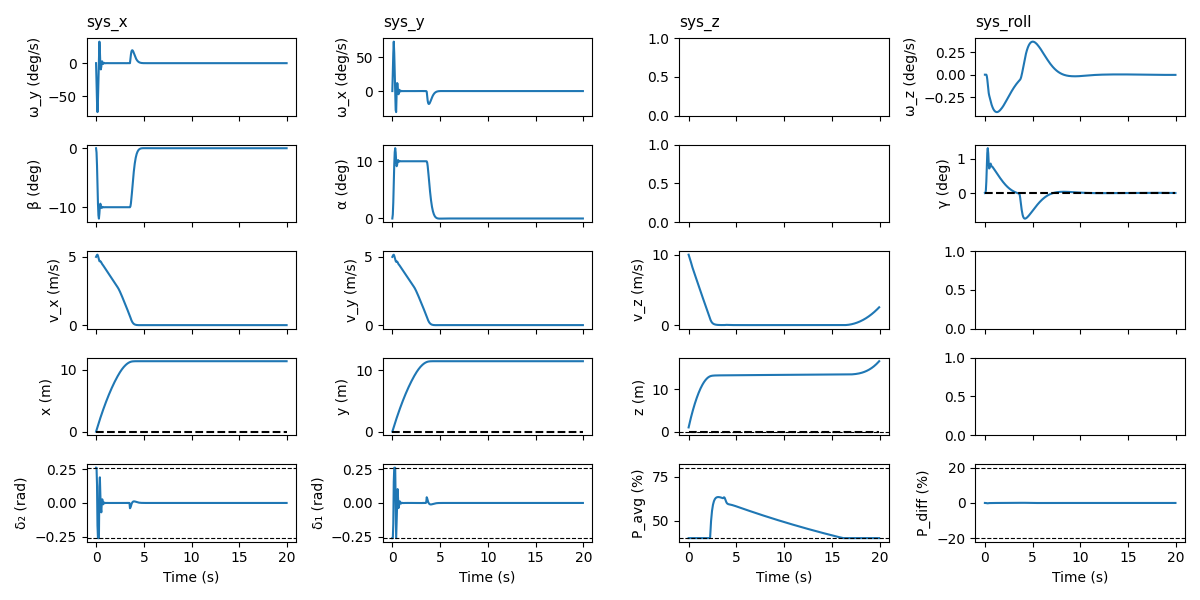

In [4]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, ref[:,:-1])

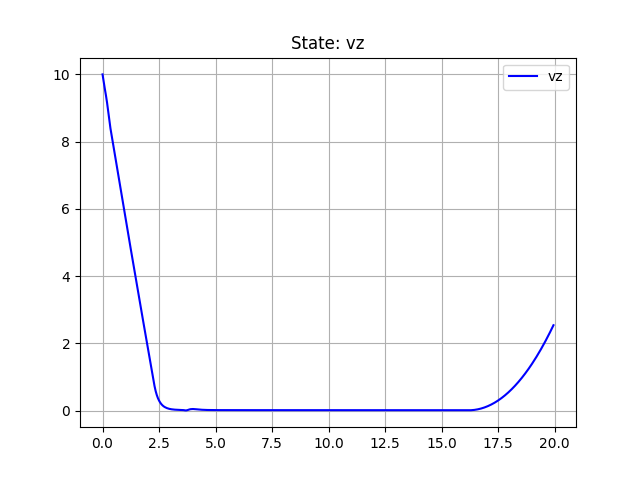

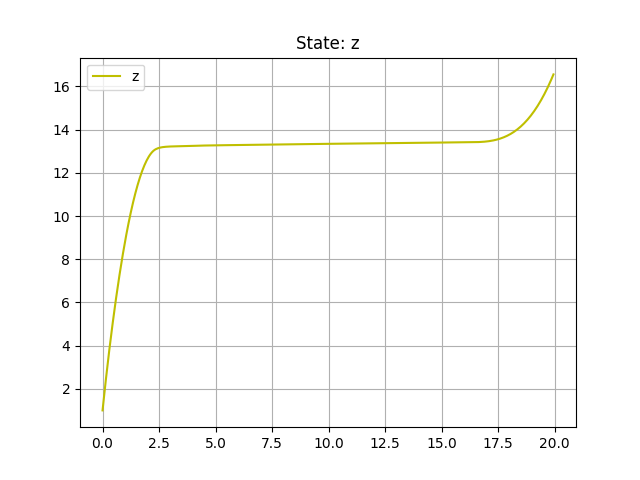

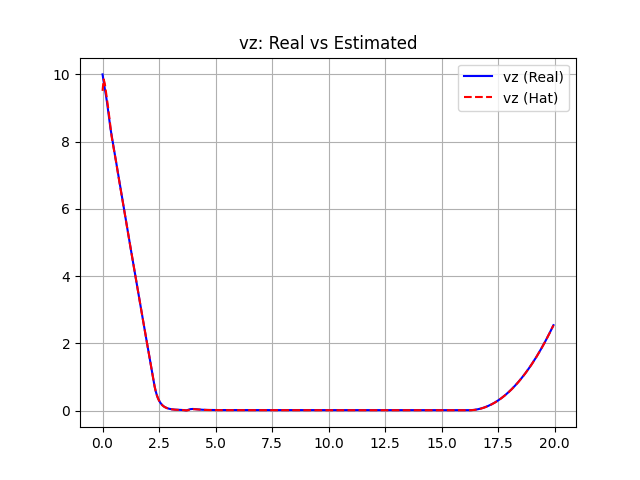

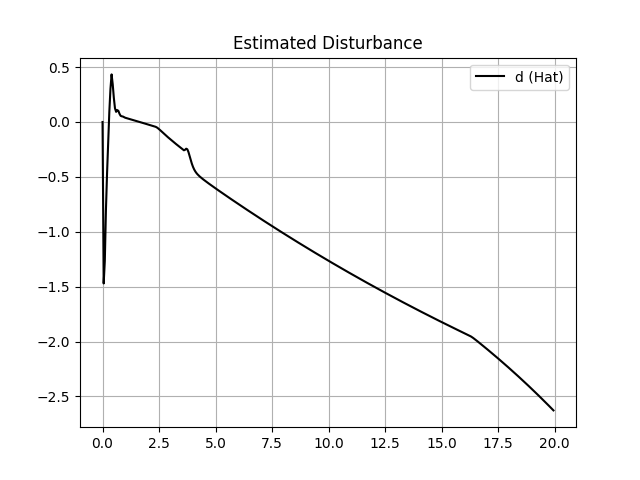

In [6]:
import matplotlib.pyplot as plt

time_axis = t_cl[:-1]
vz_real = x_cl[8, :-1]
z_real = x_cl[11, :-1]

# Plot 1: vz (Blue)
plt.figure()
plt.plot(time_axis, vz_real, 'b', label='vz')
plt.legend()
plt.title('State: vz')
plt.grid(True)
plt.show()

# Plot 2: z (Yellow)
plt.figure()
plt.plot(time_axis, z_real, 'y', label='z')
plt.legend()
plt.title('State: z')
plt.grid(True)
plt.show()

# Plot 3: vz (Real) vs vz (Hat)
vz_history = np.array(mpc.mpc_z.x_hat_history).flatten()
L = min(len(time_axis), len(vz_history))

plt.figure()
plt.plot(time_axis[:L], vz_real[:L], 'b', label='vz (Real)')
plt.plot(time_axis[:L], vz_history[:L], 'r--', label='vz (Hat)')
plt.legend()
plt.title('vz: Real vs Estimated')
plt.grid(True)
plt.show()

# Plot 4: d (Hat)
d_history = np.array(mpc.mpc_z.d_hat_history).flatten()
L_d = min(len(time_axis), len(d_history))

plt.figure()
plt.plot(time_axis[:L_d], d_history[:L_d], 'k', label='d (Hat)')
plt.legend()
plt.title('Estimated Disturbance')
plt.grid(True)
plt.show()